# Universal Rotation Curve

Below  $x = R / R_{opt}$   and $y = L_B/L_*$   where $L_* = 10^{10.4} L_{sun}$



In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.linspace(0,2,101)

In [3]:
# in some papers c(y) == 1
def c(y):
    return  (0.80 + 0.44*np.log(y)+(0.87*np.exp(-0.4*y))/(0.47+2.25*y**0.4))**0.5

In [4]:
def v0(y):
    return 200 * y**0.41 / c(y)

In [5]:
def vdisk2(x,y):
    v = (0.72+0.44*np.log(y)) * 1.97*x**1.22 / (0.61+x**2)**1.43
    return v

def vhalo2(x,y):
    v = 1.6*np.exp(-0.4*y) * x**2 / (x**2 + 2.25*y**0.4)
    return v
    
def urc(x,y):
    return v0(y) * (vdisk2(x,y) + vhalo2(x,y))**0.5

In [6]:
y=np.linspace(0.2,4,100)

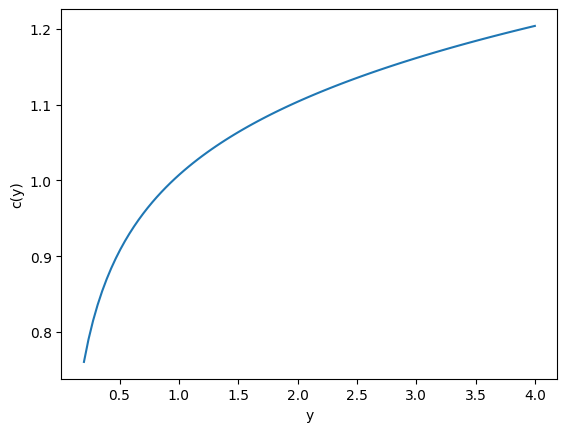

In [7]:
plt.plot(y,c(y))
plt.xlabel("y")
plt.ylabel("c(y)");

In [8]:
#  set L/L*
y=1

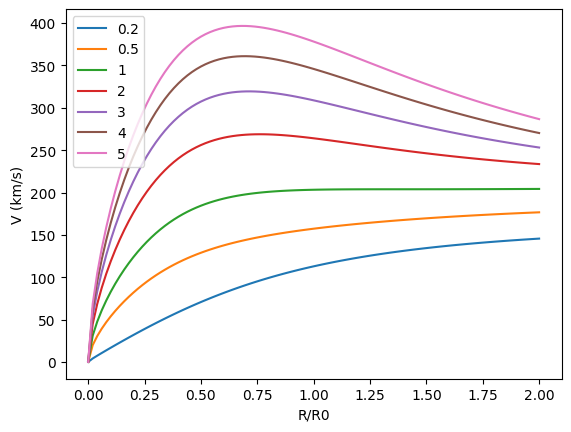

In [9]:

for y in [0.2, 0.5, 1, 2, 3, 4, 5]:
    plt.plot(x,urc(x,y), label=f"{y}")
plt.xlabel("R/R0")
plt.ylabel("V (km/s)")
plt.legend();

In [10]:
#   find VMAX w.r.t. v0 and check Tully-Fisher

In [11]:
ys = np.linspace(0.2,5,50)

vmaxs = np.zeros(len(ys))
vends = np.zeros(len(ys))
vzero = np.zeros(len(ys))

for (y,i) in zip(ys,range(len(ys))):
    v = urc(x,y)
    vmax = max(v)
    vend = v[-1]
    #print(f"{y:.1f} {vmax:.1f}  {vend:.1f}")
    vmaxs[i] = vmax
    vends[i] = vend
    vzero[i] = v0(y)

Text(0, 0.5, 'V (km/s)')

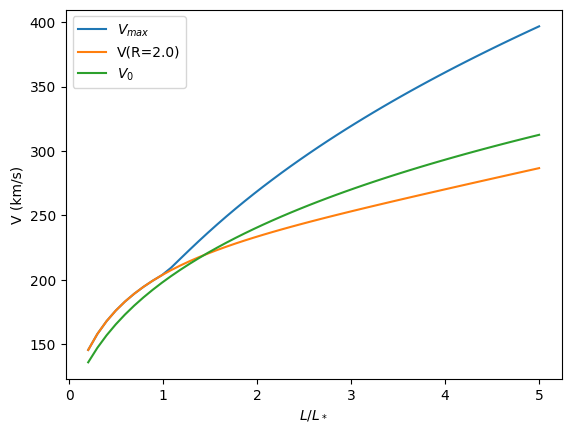

In [12]:
plt.plot(ys,vmaxs,label="$V_{max}$")
plt.plot(ys,vends,label=f"V(R={x[-1]})")
plt.plot(ys,vzero,label="$V_0$")
plt.legend()
plt.xlabel(f"$L/L_*$")
plt.ylabel(f"V (km/s)")